# Data Cleansing - Dekoruma

## Latar Belakang
Dekoruma mencatat data transaksi penjualan furnitur dari berbagai *channel* (toko fisik, web, dan mobile app), lengkap dengan data pengiriman dan pemasangan (instalasi) oleh tukang. Sebelum data ini bisa dipakai untuk analisis (misalnya performa toko, tingkat kegagalan instalasi, atau pendapatan dari biaya pasang), kita perlu memastikan datanya bersih dan konsisten.

## Data
Ada 3 file yang digunakan:
* `dekoruma_orders.csv` - data transaksi/order, mencakup tanggal order, pengiriman, instalasi, dan biaya pasang (`assembly_fee`)
* `dekoruma_products.csv` - master data produk (SKU, nama produk, kategori, apakah butuh instalasi)
* `dekoruma_stores.csv` - master data toko (nama toko, tipe channel)

Kita akan membersihkan ketiga data ini satu per satu, dimulai dari master data (`products` dan `stores`) baru kemudian data transaksi (`orders`), karena `orders` bergantung pada kedua master data tersebut.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style('whitegrid')

Mari kita baca ketiga file terlebih dahulu.

In [2]:
orders = pd.read_csv('dekoruma_orders.csv')
products = pd.read_csv('dekoruma_products.csv')
stores = pd.read_csv('dekoruma_stores.csv')

display(orders.head(), products.head(), stores.head())

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status,assembly_fee
0,ORD-DKR00000001,DKR-029,SKU-FURN-00208,2023-08-10 17:00:00,2023-08-14 17:00:00,TUKANG-0882,2023-08-18 17:00:00,Success,120000
1,ORD-DKR00000002,DKR-012,SKU-FURN-01157,2023-01-30 10:00:00,2023-02-02 10:00:00,TUKANG-0560,2023-02-02 10:00:00,Success,110000
2,ORD-DKR00000003,DKR-032,SKU-FURN-00904,2023-07-13 20:00:00,2023-07-19 20:00:00,TUKANG-0631,2023-07-24 20:00:00,Success,230000
3,ORD-DKR00000004,DKR-005,SKU-FURN-00341,2023-09-27 19:00:00,2023-10-02 19:00:00,TUKANG-0484,2023-10-04 19:00:00,Success,100000
4,ORD-DKR00000005,DKR-019,SKU-FURN-01500,2023-12-15 12:00:00,2023-12-22 12:00:00,NaN,NaN,No Assembly Service,0


,sku_id,product_name,category,is_assembly_required
0,SKU-FURN-00001,Furnitur Kayu Olahan 407,Office Chair,True
1,SKU-FURN-00002,Furnitur Kayu Olahan 536,Wardrobe,True
2,SKU-FURN-00003,Sofa Japandi Minimalis 867,Sofa,True
3,SKU-FURN-00004,Furnitur Kayu Olahan 727,Kursi Kerja,True
4,SKU-FURN-00005,Furnitur Kayu Olahan 363,Wardrobe,True


,store_id,store_name,channel_type
0,DKR-001,DEC Alam Sutera 1,Physical Store
1,DKR-002,DEC Bintaro 2,Physical Store
2,DKR-003,DEC Kemang 3,Physical Store
3,DKR-004,DEC Kelapa Gading 4,Physical Store
4,DKR-005,DEC Medan 5,Physical Store


## 1. Data Understanding & Cleaning - `dekoruma_products.csv`

Kita mulai dari data produk karena ukurannya paling kecil dan menjadi referensi (master data) untuk `orders`.

In [3]:
print(f'Jumlah baris dan kolom di dataset products adalah {products.shape}')
products.info()

Jumlah baris dan kolom di dataset products adalah (1500, 4)
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   sku_id                1500 non-null   str  
 1   product_name          1500 non-null   str  
 2   category              1500 non-null   str  
 3   is_assembly_required  1500 non-null   bool 
dtypes: bool(1), str(3)
memory usage: 36.8 KB


In [4]:
display(products.describe(include='object'), products.describe(include='bool'))

,sku_id,product_name,category
count,1500,1500,1500
unique,1500,918,11
top,SKU-FURN-00001,Hiasan Meja / Karpet Aesthetic 37,Dekorasi
freq,1,7,215


,is_assembly_required
count,1500
unique,2
top,True
freq,1119


In [5]:
# jumlah data unik tiap kolom
listItem = []
for col in products.columns:
    listItem.append([col, products[col].nunique(), products[col].unique()[:10]])

pd.DataFrame(columns=['Column Name', 'Number of Unique', 'Unique Sample'], data=listItem)

,Column Name,Number of Unique,Unique Sample
0,sku_id,1500,"[SKU-FURN-00001, SKU-FURN-00002, SKU-FURN-0000..."
1,product_name,918,"[Furnitur Kayu Olahan 407, Furnitur Kayu Olaha..."
2,category,11,"[Office Chair, Wardrobe, Sofa, Kursi Kerja, Le..."
3,is_assembly_required,2,"[True, False]"


Beberapa temuan awal:
* Dataset `products` memiliki 4 kolom dan 1.500 baris, **tidak ada data kosong** (`isna().sum()` = 0 di semua kolom).
* `sku_id` unik untuk tiap baris (tidak ada duplikat), sehingga cocok dijadikan *primary key*.
* Kolom `category` memiliki 11 nilai unik, padahal secara bisnis seharusnya hanya ada beberapa kategori furnitur saja. Ini pertanda ada *inconsistent labelling* (bahasa campuran Indonesia-Inggris dan typo).

Mari kita lihat lebih detail sebaran nilai `category`.

In [6]:
products['category'].value_counts()

category
Dekorasi        215
Sofa            214
Kursi Kerja     170
Office Chair    160
Lemari          153
Meja Makan      150
Wardrobe        125
Dining Table     84
sofabed          81
Bed              78
lmri             70
Name: count, dtype: int64

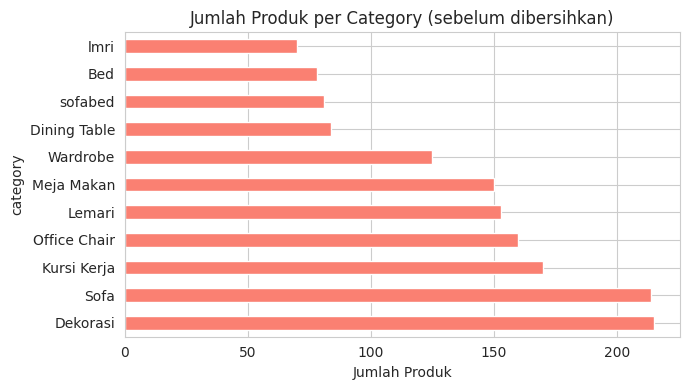

In [7]:
plt.figure(figsize=(7,4))
products['category'].value_counts().plot(kind='barh', color='salmon')
plt.title('Jumlah Produk per Category (sebelum dibersihkan)')
plt.xlabel('Jumlah Produk')
plt.tight_layout()
plt.show()

Terlihat jelas bahwa beberapa kategori sebenarnya merujuk ke hal yang sama, hanya beda bahasa/typo:
* `Kursi Kerja` (Indonesia) = `Office Chair`
* `Lemari` dan `lmri` (typo/singkatan, huruf kecil semua) = `Wardrobe`
* `Meja Makan` (Indonesia) = `Dining Table`
* `Dekorasi` (Indonesia) -> disamakan menjadi `Decoration`
* `sofabed` (huruf kecil semua) -> disamakan penulisannya menjadi `Sofabed`, dan tetap dipisah dari `Sofa` karena secara produk keduanya berbeda (sofa biasa vs sofa yang bisa jadi tempat tidur)

Kita akan menstandarkan seluruh nilai `category` ke dalam bahasa Inggris dengan format *title case* yang konsisten, supaya tiap kategori furnitur hanya direpresentasikan oleh satu label.

In [8]:
category_map = {
    'Kursi Kerja': 'Office Chair',
    'Lemari': 'Wardrobe',
    'lmri': 'Wardrobe',
    'Meja Makan': 'Dining Table',
    'Dekorasi': 'Decoration',
    'sofabed': 'Sofabed',
}

products['category'] = products['category'].replace(category_map)
products['category'].value_counts()

category
Wardrobe        348
Office Chair    330
Dining Table    234
Decoration      215
Sofa            214
Sofabed          81
Bed              78
Name: count, dtype: int64

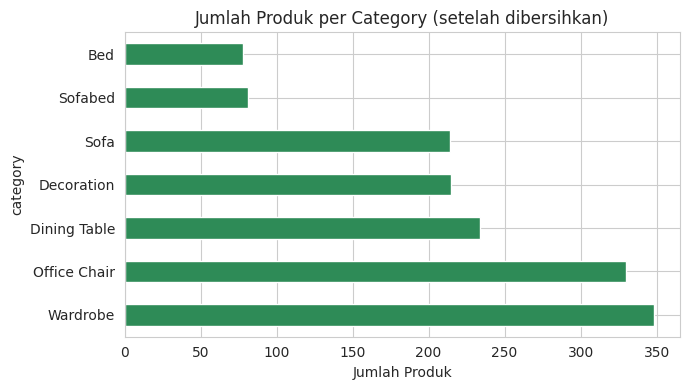

In [9]:
plt.figure(figsize=(7,4))
products['category'].value_counts().plot(kind='barh', color='seagreen')
plt.title('Jumlah Produk per Category (setelah dibersihkan)')
plt.xlabel('Jumlah Produk')
plt.tight_layout()
plt.show()

Sekarang kategori sudah rapi, dari 11 nilai unik menjadi 7 kategori furnitur yang jelas. Mari kita cek juga kolom `product_name` dan `sku_id` sekali lagi untuk memastikan tidak ada duplikat tersembunyi (misal karena spasi ekstra).

In [10]:
products['product_name'] = products['product_name'].str.strip()
print('Duplikat sku_id:', products['sku_id'].duplicated().sum())
print('Duplikat baris penuh:', products.duplicated().sum())
print('Missing value per kolom:')
print(products.isna().sum())

Duplikat sku_id: 0
Duplikat baris penuh: 0
Missing value per kolom:
sku_id                  0
product_name            0
category                0
is_assembly_required    0
dtype: int64


`products` sekarang sudah bersih: tidak ada data kosong, tidak ada duplikat, dan kategori sudah konsisten.

## 2. Data Understanding & Cleaning - `dekoruma_stores.csv`

Selanjutnya kita cek master data toko.

In [11]:
print(f'Jumlah baris dan kolom di dataset stores adalah {stores.shape}')
stores.info()

Jumlah baris dan kolom di dataset stores adalah (40, 3)
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   store_id      40 non-null     str  
 1   store_name    40 non-null     str  
 2   channel_type  40 non-null     str  
dtypes: str(3)
memory usage: 1.1 KB


In [12]:
display(stores.describe(include='object'))
print()
print('Duplikat store_id:', stores['store_id'].duplicated().sum())
print('Duplikat baris penuh:', stores.duplicated().sum())
print()
print(stores['channel_type'].value_counts())

,store_id,store_name,channel_type
count,40,40,40
unique,40,40,3
top,DKR-001,DEC Alam Sutera 1,Physical Store
freq,1,1,38



Duplikat store_id: 0
Duplikat baris penuh: 0

channel_type
Physical Store    38
Mobile App         1
Web                1
Name: count, dtype: int64


Temuan:
* Dataset `stores` memiliki 3 kolom dan 40 baris, **tidak ada data kosong** dan **tidak ada duplikat**.
* `store_id` unik untuk tiap baris.
* `channel_type` hanya berisi 3 kategori yang valid dan konsisten (`Physical Store`, `Mobile App`, `Web`), tidak ada typo.

Dataset ini sudah bersih dari awal, tidak diperlukan penanganan lebih lanjut selain memastikan tidak ada spasi ekstra di nama toko.

In [13]:
stores['store_name'] = stores['store_name'].str.strip()
stores.head()

,store_id,store_name,channel_type
0,DKR-001,DEC Alam Sutera 1,Physical Store
1,DKR-002,DEC Bintaro 2,Physical Store
2,DKR-003,DEC Kemang 3,Physical Store
3,DKR-004,DEC Kelapa Gading 4,Physical Store
4,DKR-005,DEC Medan 5,Physical Store


## 3. Data Understanding & Cleaning - `dekoruma_orders.csv`

Ini adalah dataset transaksi utama. Mari kita mulai dengan melihat gambaran umum.

In [14]:
print(f'Jumlah baris dan kolom di dataset orders adalah {orders.shape}')
orders.info()

Jumlah baris dan kolom di dataset orders adalah (300000, 9)
<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   order_id             300000 non-null  str  
 1   store_id             300000 non-null  str  
 2   sku_id               300000 non-null  str  
 3   order_date           300000 non-null  str  
 4   delivery_date        300000 non-null  str  
 5   installer_id         190275 non-null  str  
 6   installation_date    190275 non-null  str  
 7   installation_status  300000 non-null  str  
 8   assembly_fee         300000 non-null  int64
dtypes: int64(1), str(8)
memory usage: 20.6 MB


In [15]:
display(orders.describe(include='object'))
orders.describe()

,order_id,store_id,sku_id,order_date,delivery_date,installer_id,installation_date,installation_status
count,300000,300000,300000,300000,300000,190275,190275,300000
unique,300000,40,1500,4380,4440,999,4498,5
top,ORD-DKR00000001,DKR-021,SKU-FURN-01422,2023-07-16 20:00:00,2023-02-07 19:00:00,TUKANG-0795,2023-09-04 20:00:00,Success
freq,1,7769,261,99,103,244,70,152357


,assembly_fee
count,3.000000e+05
mean,4.044456e+05
std,5.557956e+06
min,-1.500000e+05
25%,0.000000e+00
50%,9.000000e+04
75%,1.700000e+05
max,9.990000e+07


Beberapa observasi awal:
* Dataset `orders` memiliki 9 kolom dan 300.000 baris.
* Kolom `installer_id` dan `installation_date` punya banyak data kosong.
* Kolom `assembly_fee` bertipe numerik, tapi nilai `min` nya negatif (`-150000`) dan nilai `max` nya sangat besar (`99900000`, hampir 100 juta) - ini janggal untuk biaya pasang furnitur, jadi kemungkinan besar ada anomali/*outlier*.
* Kolom tanggal (`order_date`, `delivery_date`, `installation_date`) masih bertipe teks (`object`), perlu diubah ke tipe *datetime* supaya bisa dianalisis secara kronologis.

Mari kita cek satu per satu, dimulai dari duplikat dan validitas referensi ke master data.

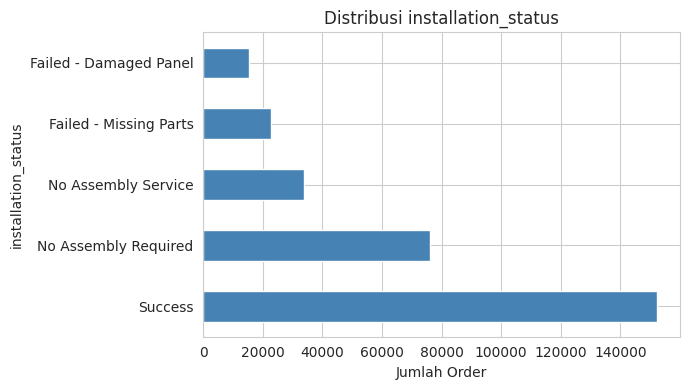

In [16]:
plt.figure(figsize=(7,4))
orders['installation_status'].value_counts().plot(kind='barh', color='steelblue')
plt.title('Distribusi installation_status')
plt.xlabel('Jumlah Order')
plt.tight_layout()
plt.show()

In [17]:
print('Duplikat order_id:', orders['order_id'].duplicated().sum())
print('Duplikat baris penuh:', orders.duplicated().sum())
print()
print('store_id di orders yang tidak ada di master stores:', (~orders['store_id'].isin(stores['store_id'])).sum())
print('sku_id di orders yang tidak ada di master products:', (~orders['sku_id'].isin(products['sku_id'])).sum())

Duplikat order_id: 0


Duplikat baris penuh: 0

store_id di orders yang tidak ada di master stores: 0
sku_id di orders yang tidak ada di master products: 0


Tidak ada duplikat, dan seluruh `store_id`/`sku_id` di `orders` valid (ada di master data). Sekarang mari kita ubah kolom tanggal menjadi tipe *datetime*.

In [18]:
for col in ['order_date', 'delivery_date', 'installation_date']:
    orders[col] = pd.to_datetime(orders[col])

orders.dtypes

order_id                          str
store_id                          str
sku_id                            str
order_date             datetime64[us]
delivery_date          datetime64[us]
installer_id                      str
installation_date      datetime64[us]
installation_status               str
assembly_fee                    int64
dtype: object

### Missing Value pada `installer_id` dan `installation_date`

Mari kita lihat persentase data kosong di tiap kolom.

In [19]:
orders.isna().sum() / orders.shape[0] * 100

order_id                0.000
store_id                0.000
sku_id                  0.000
order_date              0.000
delivery_date           0.000
installer_id           36.575
installation_date      36.575
installation_status     0.000
assembly_fee            0.000
dtype: float64

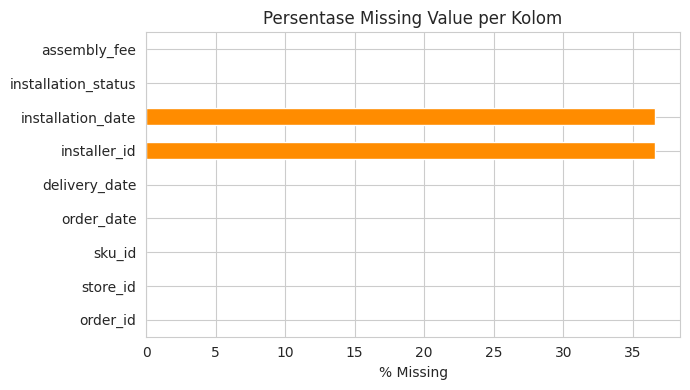

In [20]:
plt.figure(figsize=(7,4))
(orders.isna().sum() / orders.shape[0] * 100).plot(kind='barh', color='darkorange')
plt.title('Persentase Missing Value per Kolom')
plt.xlabel('% Missing')
plt.tight_layout()
plt.show()

Kolom `installer_id` dan `installation_date` sama-sama memiliki 36,58% data kosong (109.725 baris). Karena jumlahnya sama persis, kemungkinan besar kedua data kosong ini saling berkaitan. Mari kita cek, apakah baris-baris dengan `installer_id` kosong punya pola tertentu pada `installation_status`.

In [21]:
orders[orders['installer_id'].isna()]['installation_status'].value_counts()

installation_status
No Assembly Required    76030
No Assembly Service     33695
Name: count, dtype: int64

In [22]:
orders[orders['installer_id'].notna()]['installation_status'].value_counts()

installation_status
Success                   152357
Failed - Missing Parts     22639
Failed - Damaged Panel     15279
Name: count, dtype: int64

Polanya sangat jelas:
* Baris dengan `installer_id` (dan `installation_date`) kosong **selalu** berstatus `No Assembly Required` (produk memang tidak butuh dipasang) atau `No Assembly Service` (butuh dipasang tapi customer tidak menggunakan jasa pasang dari Dekoruma).
* Baris dengan `installer_id` terisi selalu berstatus `Success`, `Failed - Missing Parts`, atau `Failed - Damaged Panel` - yaitu status yang menandakan proses instalasi memang benar-benar terjadi (baik berhasil maupun gagal).

Jadi, data kosong ini **bukan merupakan data yang hilang/error**, melainkan memang secara logis tidak ada tukang atau tanggal instalasi karena instalasi tidak dilakukan. Kita akan:
* mengisi `installer_id` dengan label `'Not Applicable'` supaya jelas maknanya saat dianalisis sebagai kategori,
* membiarkan `installation_date` tetap kosong (`NaT`), karena mengisi tanggal palsu untuk instalasi yang tidak pernah terjadi justru akan menyesatkan analisis.

Mari kita validasi dulu dengan kolom `is_assembly_required` dari master `products`.

In [23]:
check = orders.merge(products[['sku_id', 'is_assembly_required']], on='sku_id', how='left')
pd.crosstab(check['is_assembly_required'], check['installation_status'])

installation_status,Failed - Damaged Panel,Failed - Missing Parts,No Assembly Required,No Assembly Service,Success
is_assembly_required,,,,,
False,0,0,76030,0,0
True,15279,22639,0,33695,152357


Terkonfirmasi: seluruh baris dengan `is_assembly_required = False` selalu berstatus `No Assembly Required` (76.030 baris, persis sama dengan jumlah SKU yang memang tidak butuh instalasi). Ini memperkuat kesimpulan bahwa data kosong pada `installer_id`/`installation_date` adalah *structural missing*, bukan error.

In [24]:
orders['installer_id'] = orders['installer_id'].fillna('Not Applicable')
orders.isna().sum()

order_id                    0
store_id                    0
sku_id                      0
order_date                  0
delivery_date               0
installer_id                0
installation_date      109725
installation_status         0
assembly_fee                0
dtype: int64

### Anomali pada `assembly_fee`

Sebelumnya kita lihat `assembly_fee` punya nilai minimum negatif dan maksimum yang tidak masuk akal. Mari kita telusuri lebih jauh.

In [25]:
orders.groupby('installation_status')['assembly_fee'].describe()

,count,mean,std,min,25%,50%,75%,max
installation_status,,,,,,,,
Failed - Damaged Panel,15279.0,632004.057857,6.925716e+06,-150000.0,100000.0,150000.0,200000.0,99900000.0
Failed - Missing Parts,22639.0,637524.625646,6.968076e+06,-150000.0,100000.0,150000.0,200000.0,99900000.0
No Assembly Required,76030.0,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0
No Assembly Service,33695.0,0.000000,0.000000e+00,0.0,0.0,0.0,0.0,0.0
Success,152357.0,638266.571277,6.972521e+06,-150000.0,100000.0,150000.0,200000.0,99900000.0


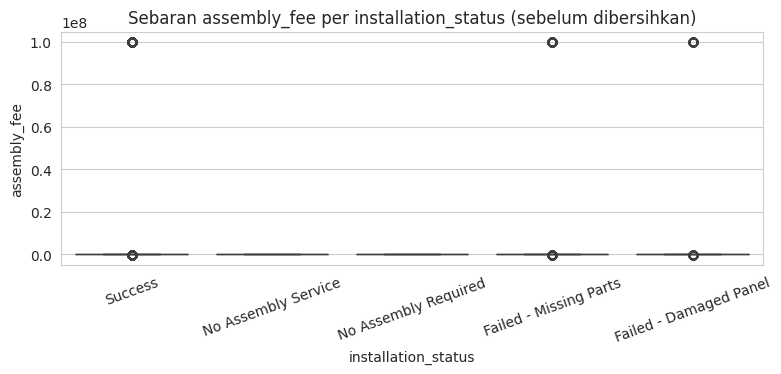

In [26]:
plt.figure(figsize=(8,4))
sns.boxplot(data=orders, x='installation_status', y='assembly_fee')
plt.xticks(rotation=20)
plt.title('Sebaran assembly_fee per installation_status (sebelum dibersihkan)')
plt.tight_layout()
plt.show()

Dari tabel di atas terlihat:
* Untuk status `No Assembly Required` dan `No Assembly Service`, `assembly_fee` selalu **0** - ini masuk akal karena memang tidak ada biaya pasang jika instalasi tidak dilakukan. **Nilai 0 ini valid, bukan anomali.**
* Untuk status `Success`, `Failed - Missing Parts`, dan `Failed - Damaged Panel` (instalasi benar-benar dilakukan), rata-rata *fee* berada di kisaran wajar, tapi standar deviasinya sangat besar - menandakan ada outlier ekstrem.

Mari kita lihat sebaran nilai `assembly_fee` yang valid (di luar 0) untuk memahami pola normalnya.

In [27]:
normal_fee = orders[(orders['assembly_fee'] > 0) & (orders['assembly_fee'] < 1_000_000)]
normal_fee['assembly_fee'].value_counts().sort_index()

assembly_fee
50000     9092
60000     8917
70000     8973
80000     8874
90000     8807
100000    8941
110000    8897
120000    8924
130000    9081
140000    9029
150000    8924
160000    9034
170000    9089
180000    8986
190000    8984
200000    8956
210000    9044
220000    8912
230000    9089
240000    8994
250000    8835
Name: count, dtype: int64

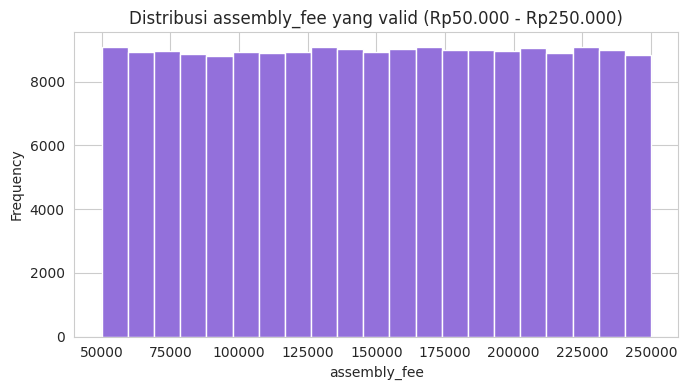

In [28]:
plt.figure(figsize=(7,4))
normal_fee['assembly_fee'].plot(kind='hist', bins=21, color='mediumpurple', edgecolor='white')
plt.title('Distribusi assembly_fee yang valid (Rp50.000 - Rp250.000)')
plt.xlabel('assembly_fee')
plt.tight_layout()
plt.show()

Untuk order yang benar-benar diinstalasi, `assembly_fee` normalnya berkisar antara **Rp50.000 - Rp250.000**, berkelipatan Rp10.000, dengan jumlah baris yang cukup merata di tiap nilai (~9.000 baris masing-masing). Ini adalah pola/rentang harga yang wajar.

Sekarang mari kita lihat 2 jenis anomali yang muncul sebelumnya:

In [29]:
print('Jumlah baris dengan assembly_fee = -150.000 :', (orders['assembly_fee'] == -150000).sum())
print('Jumlah baris dengan assembly_fee = 99.900.000 :', (orders['assembly_fee'] == 99900000).sum())
print()
print('Status instalasi utk fee = -150.000:')
print(orders[orders['assembly_fee'] == -150000]['installation_status'].value_counts())
print()
print('Status instalasi utk fee = 99.900.000:')
print(orders[orders['assembly_fee'] == 99900000]['installation_status'].value_counts())

Jumlah baris dengan assembly_fee = -150.000 : 960
Jumlah baris dengan assembly_fee = 99.900.000 : 933

Status instalasi utk fee = -150.000:
installation_status
Success                   786
Failed - Missing Parts    100
Failed - Damaged Panel     74
Name: count, dtype: int64

Status instalasi utk fee = 99.900.000:
installation_status
Success                   748
Failed - Missing Parts    111
Failed - Damaged Panel     74
Name: count, dtype: int64


Dua jenis anomali ini muncul pada status yang sama dengan *fee* normal (`Success`, `Failed - Missing Parts`, `Failed - Damaged Panel`), namun keduanya kita perlakukan berbeda karena kemungkinan penyebabnya berbeda:

* **`-150.000` (960 baris)**: nilai negatif untuk sebuah *fee* memang tidak lazim, tapi besarnya (Rp150.000) persis sama dengan salah satu nilai normal yang valid dalam rentang Rp50.000-Rp250.000. Ini mengindikasikan nilai negatif kemungkinan besar bukan angka acak/error input, melainkan representasi dari **kompensasi atau diskon** yang diberikan Dekoruma kepada pelanggan (misalnya karena keterlambatan, atau sebagai bagian dari penyelesaian kasus instalasi) - jadi assembly_fee tercatat sebagai pengembalian/potongan biaya. Karena ada justifikasi bisnis yang masuk akal, **nilai ini kita pertahankan apa adanya (tidak diubah)**.
* **`99.900.000` (933 baris)**: nilai ini jauh di luar rentang wajar (hampir 100 juta rupiah untuk biaya pasang furnitur) dan tidak match dengan pola nilai valid manapun (bukan kelipatan wajar, bukan representasi kompensasi yang masuk akal), sehingga tetap kita anggap sebagai *data entry error* murni dan **tidak bisa kita tebak nilai aslinya**. Untuk kasus ini, cara terbaik adalah mengganti nilai anomali dengan **median dari fee yang valid** (Rp150.000), mengikuti pola dari mayoritas data yang sudah bersih, daripada membiarkan nilai ekstrem ini merusak analisis (misalnya perhitungan rata-rata pendapatan biaya pasang).

Total baris yang diimputasi: 933 dari 190.275 baris dengan instalasi (~0,5%) - proporsinya kecil, sehingga koreksi ini tidak akan mengubah gambaran besar data secara signifikan.

In [30]:
median_fee = normal_fee['assembly_fee'].median()
print('Median fee yang dipakai untuk imputasi:', median_fee)

# nilai -150.000 dipertahankan (kemungkinan kompensasi/diskon), tidak diubah

# imputasi outlier ekstrem dengan median
orders.loc[orders['assembly_fee'] == 99900000, 'assembly_fee'] = median_fee

orders.groupby('installation_status')['assembly_fee'].describe()

Median fee yang dipakai untuk imputasi: 150000.0


,count,mean,std,min,25%,50%,75%,max
installation_status,,,,,,,,
Failed - Damaged Panel,15279.0,148889.979711,64026.015613,-150000.0,100000.0,150000.0,200000.0,250000.0
Failed - Missing Parts,22639.0,148446.044437,63413.352569,-150000.0,100000.0,150000.0,200000.0,250000.0
No Assembly Required,76030.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
No Assembly Service,33695.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
Success,152357.0,148541.780161,63907.425167,-150000.0,100000.0,150000.0,200000.0,250000.0


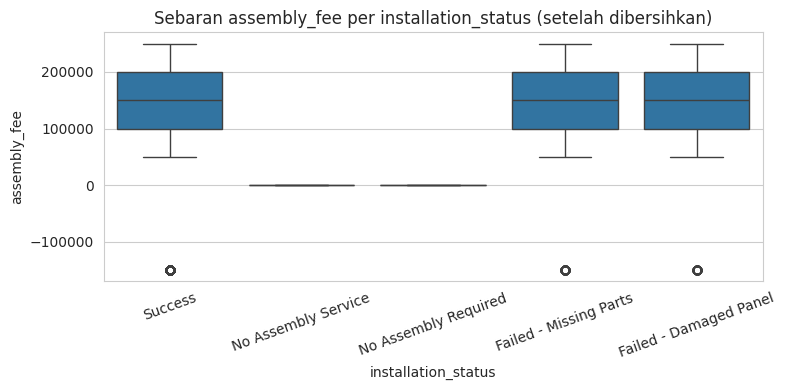

In [31]:
plt.figure(figsize=(8,4))
sns.boxplot(data=orders, x='installation_status', y='assembly_fee')
plt.xticks(rotation=20)
plt.title('Sebaran assembly_fee per installation_status (setelah dibersihkan)')
plt.tight_layout()
plt.show()

Sekarang `assembly_fee` sudah berada di rentang yang wajar (Rp0 - Rp250.000) untuk semua status instalasi.

### Konsistensi Urutan Tanggal

Secara logis, urutan tanggal seharusnya: `order_date` <= `delivery_date` <= `installation_date` (barang harus dipesan dulu, dikirim, baru dipasang). Mari kita cek apakah ada baris yang melanggar urutan ini.

In [32]:
bad_order_delivery = (orders['delivery_date'] < orders['order_date']).sum()
bad_delivery_install = (orders['installation_date'] < orders['delivery_date']).sum()

print('delivery_date sebelum order_date:', bad_order_delivery)
print('installation_date sebelum delivery_date:', bad_delivery_install)

delivery_date sebelum order_date: 0
installation_date sebelum delivery_date: 4570


Tidak ada masalah antara `order_date` dan `delivery_date`. Namun ada **4.570 baris** di mana `installation_date` justru lebih awal dari `delivery_date` - ini tidak masuk akal karena furnitur tidak mungkin dipasang sebelum diantar.

Karena kita tidak punya cara untuk mengetahui tanggal mana yang benar (`delivery_date` atau `installation_date`) dan jumlahnya relatif kecil (±2,4% dari baris yang punya `installation_date`), baris-baris ini akan **dihapus** saja, mengikuti pendekatan yang sama seperti pada contoh sebelumnya untuk data yang tidak bisa dikoreksi.

In [33]:
idx_bad_dates = orders[orders['installation_date'] < orders['delivery_date']].index
orders = orders.drop(index=idx_bad_dates)

print('Jumlah baris setelah menghapus data dengan urutan tanggal tidak valid:', orders.shape[0])
print('installation_date sebelum delivery_date (setelah dibersihkan):', (orders['installation_date'] < orders['delivery_date']).sum())

Jumlah baris setelah menghapus data dengan urutan tanggal tidak valid: 295430
installation_date sebelum delivery_date (setelah dibersihkan): 0


### Pengecekan Akhir

In [34]:
orders.isna().sum()

order_id                    0
store_id                    0
sku_id                      0
order_date                  0
delivery_date               0
installer_id                0
installation_date      109725
installation_status         0
assembly_fee                0
dtype: int64

Data kosong yang tersisa hanya di `installation_date`, dan ini memang sudah kita putuskan untuk dibiarkan (bukan error, melainkan instalasi yang memang tidak terjadi).

## Data yang Sudah Bersih

Ringkasan hasil pembersihan data:

In [35]:
for name, before, after in [
    ('products', 1500, products.shape[0]),
    ('stores', 40, stores.shape[0]),
    ('orders', 300000, orders.shape[0]),
]:
    print(f'{name:10s}: {before:>7,} baris -> {after:>7,} baris')

products  :   1,500 baris ->   1,500 baris
stores    :      40 baris ->      40 baris
orders    : 300,000 baris -> 295,430 baris


Ringkasan langkah pembersihan yang dilakukan:

**`dekoruma_products.csv`**
* Menstandarkan 11 nilai `category` yang campur bahasa/typo menjadi 7 kategori yang konsisten.
* Menghapus spasi ekstra pada `product_name`.

**`dekoruma_stores.csv`**
* Data sudah bersih sejak awal (tidak ada data kosong maupun duplikat), hanya dirapikan spasi pada `store_name`.

**`dekoruma_orders.csv`**
* Mengubah kolom tanggal ke tipe *datetime*.
* Data kosong pada `installer_id`/`installation_date` (36,6%) dikonfirmasi sebagai *structural missing* (instalasi memang tidak dilakukan) - `installer_id` diisi `'Not Applicable'`, `installation_date` dibiarkan kosong.
* Anomali pada `assembly_fee`: nilai negatif (`-150.000`) dipertahankan (kemungkinan representasi kompensasi/diskon ke pelanggan), sementara nilai ekstrem (`99.900.000`) diimputasi dengan median fee yang valid (`150.000`).
* Menghapus 4.570 baris dengan urutan tanggal yang tidak logis (`installation_date` sebelum `delivery_date`).

Ketiga dataset sekarang siap digunakan untuk tahap analisis selanjutnya.

In [36]:
orders.to_csv('dekoruma_orders_clean.csv', index=False)
products.to_csv('dekoruma_products_clean.csv', index=False)
stores.to_csv('dekoruma_stores_clean.csv', index=False)
print('Selesai disimpan.')

Selesai disimpan.
